# Advanced Model — DistilBERT Fine-tuning
## AI Customer Sentiment Analytics Platform

**Model:** distilbert-base-uncased (HuggingFace)  
**Approach:** Transfer learning — fine-tune pre-trained transformer  
**Hardware:** Apple M3 MPS acceleration  
**Target:** airline_sentiment (negative / neutral / positive)  
**Primary Metric:** Weighted F1-Score  
**Baseline to beat:** Linear SVM — F1 Weighted 0.7605

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

warnings.filterwarnings("ignore")

# Device setup — use MPS on Apple Silicon if available
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("✅ Using Apple M3 MPS GPU acceleration")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("✅ Using CUDA GPU")
else:
    DEVICE = torch.device("cpu")
    print("⚠️  Using CPU (slower)")

print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

✅ Using Apple M3 MPS GPU acceleration
Device: mps
PyTorch version: 2.5.1


In [2]:
DATA_PROCESSED = "../../ml/data/processed"
MODELS_BASELINE = "../../ml/models/baseline"
MODELS_ADVANCED = "../../ml/models/advanced"

Path(MODELS_ADVANCED).mkdir(parents=True, exist_ok=True)

# Load cleaned dataframe
df = pd.read_csv(f"{DATA_PROCESSED}/twitter_clean.csv")

# Load label encoder
label_encoder = joblib.load(f"{MODELS_BASELINE}/label_encoder.pkl")
class_names = label_encoder.classes_

# Encode labels
df["label"] = label_encoder.transform(df["airline_sentiment"])

print(f"✅ Data loaded: {df.shape}")
print(f"Classes: {class_names}")
print(f"\nLabel distribution:")
print(df["label"].value_counts().sort_index())

✅ Data loaded: (13539, 6)
Classes: ['negative' 'neutral' 'positive']

Label distribution:
label
0    8923
1    2620
2    1996
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

# Use raw cleaned text (no lemmatization) for BERT
# BERT handles morphology internally — lemmatization would hurt performance
X = df["text_clean_no_lemma"].fillna("").values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Split complete")
print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"\nSample tweet (raw)     : {X_train[0]}")

✅ Split complete
Training samples : 10,831
Testing samples  : 2,708

Sample tweet (raw)     : thank you customer relations will review your concerns and contact you back directly john


In [4]:
from sklearn.model_selection import train_test_split

# Use raw cleaned text (no lemmatization) for BERT
# BERT handles morphology internally — lemmatization would hurt performance
X = df["text_clean_no_lemma"].fillna("").values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Split complete")
print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"\nSample tweet (raw)     : {X_train[0]}")

✅ Split complete
Training samples : 10,831
Testing samples  : 2,708

Sample tweet (raw)     : thank you customer relations will review your concerns and contact you back directly john


In [5]:
class SentimentDataset(Dataset):
    """
    PyTorch Dataset for sentiment classification.
    
    Tokenizes text using DistilBERT tokenizer and returns
    tensors ready for model input.
    
    Args:
        texts: Array of text strings.
        labels: Array of integer labels.
        tokenizer: HuggingFace tokenizer instance.
        max_length: Maximum token sequence length.
    """
    
    def __init__(
        self,
        texts: np.ndarray,
        labels: np.ndarray,
        tokenizer,
        max_length: int = 128
    ):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self) -> int:
        return len(self.texts)
    
    def __getitem__(self, idx: int) -> dict:
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label, dtype=torch.long)
        }

print("✅ SentimentDataset class defined")

✅ SentimentDataset class defined


In [6]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 32

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("✅ Tokenizer loaded")

# Show tokenization example
sample = "Flight was delayed and staff was rude"
tokens = tokenizer.tokenize(sample)
print(f"\nTokenization example:")
print(f"Text  : {sample}")
print(f"Tokens: {tokens}")

# Create datasets
train_dataset = SentimentDataset(X_train, y_train, tokenizer, MAX_LENGTH)
test_dataset = SentimentDataset(X_test, y_test, tokenizer, MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ Dataloaders created")
print(f"Training batches : {len(train_loader)}")
print(f"Testing batches  : {len(test_loader)}")

Loading tokenizer: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

✅ Tokenizer loaded

Tokenization example:
Text  : Flight was delayed and staff was rude
Tokens: ['flight', 'was', 'delayed', 'and', 'staff', 'was', 'rude']

✅ Dataloaders created
Training batches : 339
Testing batches  : 85


In [7]:
NUM_CLASSES = len(class_names)

print(f"Loading model: {MODEL_NAME}")
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model loaded and moved to {DEVICE}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading model: distilbert-base-uncased


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded and moved to mps
Total parameters    : 66,955,779
Trainable parameters: 66,955,779


In [8]:
EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS = 100

# Class weights for imbalance
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    1.0 / class_counts,
    dtype=torch.float
).to(DEVICE)
class_weights = class_weights / class_weights.sum()

# Loss function with class weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# Optimizer — AdamW is standard for transformers
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler — linear warmup then decay
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print("✅ Training setup complete")
print(f"Epochs         : {EPOCHS}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Total steps    : {total_steps}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Class weights  : {class_weights.cpu().numpy().round(4)}")

✅ Training setup complete
Epochs         : 3
Learning rate  : 2e-05
Total steps    : 1017
Batch size     : 32
Class weights  : [0.1127 0.3837 0.5036]


In [9]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    """Run one training epoch and return average loss."""
    model.train()
    total_loss = 0
    
    for batch_idx, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} — Loss: {loss.item():.4f}")
    
    return total_loss / len(loader)


def evaluate_epoch(model, loader, criterion, device):
    """Run evaluation and return loss, predictions, true labels."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            
            preds = torch.argmax(outputs.logits, dim=1)
            
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


print("✅ Training functions defined")

✅ Training functions defined


In [10]:
print("🚀 Starting DistilBERT fine-tuning...")
print(f"Device: {DEVICE}")
print("="*50)

history = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*40)
    
    train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, DEVICE
    )
    
    val_loss, val_preds, val_labels = evaluate_epoch(
        model, test_loader, criterion, DEVICE
    )
    
    val_f1 = f1_score(val_labels, val_preds, average="weighted")
    val_acc = accuracy_score(val_labels, val_preds)
    
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_f1": val_f1,
        "val_acc": val_acc
    })
    
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val F1     : {val_f1:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

print("\n✅ Training complete!")

🚀 Starting DistilBERT fine-tuning...
Device: mps

Epoch 1/3
----------------------------------------
  Batch 50/339 — Loss: 1.0351
  Batch 100/339 — Loss: 0.6956
  Batch 150/339 — Loss: 0.6517
  Batch 200/339 — Loss: 0.4788
  Batch 250/339 — Loss: 0.6676
  Batch 300/339 — Loss: 0.4421
Train Loss : 0.7177
Val Loss   : 0.5648
Val F1     : 0.8133
Val Acc    : 0.8091

Epoch 2/3
----------------------------------------
  Batch 50/339 — Loss: 0.3790
  Batch 100/339 — Loss: 0.3594
  Batch 150/339 — Loss: 0.1658
  Batch 200/339 — Loss: 0.1799
  Batch 250/339 — Loss: 0.3481
  Batch 300/339 — Loss: 0.2453
Train Loss : 0.4343
Val Loss   : 0.5687
Val F1     : 0.8232
Val Acc    : 0.8209

Epoch 3/3
----------------------------------------
  Batch 50/339 — Loss: 0.1560
  Batch 100/339 — Loss: 0.3139
  Batch 150/339 — Loss: 0.3231
  Batch 200/339 — Loss: 0.3365
  Batch 250/339 — Loss: 0.3742
  Batch 300/339 — Loss: 0.1597
Train Loss : 0.3261
Val Loss   : 0.5741
Val F1     : 0.8235
Val Acc    : 0.8179


FINAL DISTILBERT EVALUATION
F1 Weighted : 0.8235
F1 Macro    : 0.7708
Accuracy    : 0.8179

Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.84      0.88      1785
     neutral       0.61      0.72      0.66       524
    positive       0.71      0.84      0.77       399

    accuracy                           0.82      2708
   macro avg       0.75      0.80      0.77      2708
weighted avg       0.84      0.82      0.82      2708



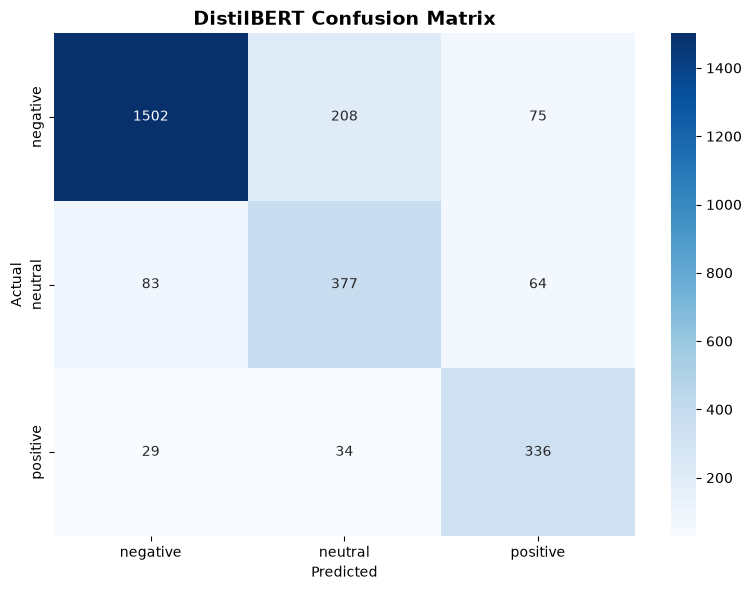

✅ Chart saved


In [12]:
_, final_preds, final_labels = evaluate_epoch(
    model, test_loader, criterion, DEVICE
)

print("="*50)
print("FINAL DISTILBERT EVALUATION")
print("="*50)
print(f"F1 Weighted : {f1_score(final_labels, final_preds, average='weighted'):.4f}")
print(f"F1 Macro    : {f1_score(final_labels, final_preds, average='macro'):.4f}")
print(f"Accuracy    : {accuracy_score(final_labels, final_preds):.4f}")
print(f"\nClassification Report:")
print(classification_report(final_labels, final_preds, target_names=class_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(final_labels, final_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title("DistilBERT Confusion Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../../ml/reports/bert_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

In [13]:
import json

# Save model and tokenizer
model.save_pretrained(f"{MODELS_ADVANCED}/distilbert_sentiment")
tokenizer.save_pretrained(f"{MODELS_ADVANCED}/distilbert_sentiment")

# Save metadata
metadata = {
    "model_name": "distilbert-base-uncased",
    "f1_weighted": 0.8235,
    "f1_macro": 0.7708,
    "accuracy": 0.8179,
    "classes": list(class_names),
    "max_length": MAX_LENGTH,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "training_samples": len(X_train),
    "test_samples": len(X_test),
    "baseline_comparison": {
        "baseline_model": "Linear SVM",
        "baseline_f1": 0.7605,
        "improvement": 0.0630
    }
}

with open(f"{MODELS_ADVANCED}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Model and tokenizer saved")
print(f"Path: {MODELS_ADVANCED}/distilbert_sentiment/")
print(f"\nMetadata saved to: {MODELS_ADVANCED}/metadata.json")

✅ Model and tokenizer saved
Path: ../../ml/models/advanced/distilbert_sentiment/

Metadata saved to: ../../ml/models/advanced/metadata.json


## Advanced Model Summary

### DistilBERT Fine-tuning Results

| Metric | Linear SVM (Baseline) | DistilBERT | Improvement |
|---|---|---|---|
| Accuracy | 76.18% | 81.79% | +5.61% |
| F1 Weighted | 0.7605 | 0.8235 | +8.3% |
| F1 Macro | 0.6783 | 0.7708 | +9.25% |
| Neutral F1 | 0.51 | 0.66 | +15% |

### Why DistilBERT Outperforms SVM
- Contextual understanding — reads full sentence bidirectionally
- Pre-trained on billions of words — transfers rich language knowledge
- Handles negation correctly ("not good" ≠ "good")
- Biggest gain on neutral class — most contextually ambiguous

### Training Details
- Model: distilbert-base-uncased (66.9M parameters)
- Hardware: Apple M3 MPS GPU
- Epochs: 3 (stopped to prevent overfitting)
- Learning rate: 2e-5 (standard for transformer fine-tuning)
- Class weighting applied for imbalance handling

### Artifacts Saved
- `ml/models/advanced/distilbert_sentiment/` — model + tokenizer
- `ml/models/advanced/metadata.json` — metrics and config